In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve

from copy import deepcopy
from jax.lax import slice as jax_slice
from scipy.signal import convolve

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)

        self.space = space
        self.factor = factor
        self.center = center
        self.shape = tuple(d*self.factor for d in self.space)

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor})'

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()

    @property
    def llp(self):
        return (self.cen - 0.5 * (self.dom - 1)) * self.factor

    @property
    def urp(self):
        return (self.cen + 0.5 * (self.dom - 1)) * self.factor

    def update(self, space=None, center=None, factor=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        return SignalGrid(space, center, factor)



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_grid = in_grid.update(factor=out_grid.factor)
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center:
        out_array = np.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif, 0)
        in_max = np.minimum(urp_dif + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif, 0)
        out_max = np.minimum(out_grid.shp - urp_dif, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array[out_slc] = in_array[in_slc]
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

In [3]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val

In [4]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


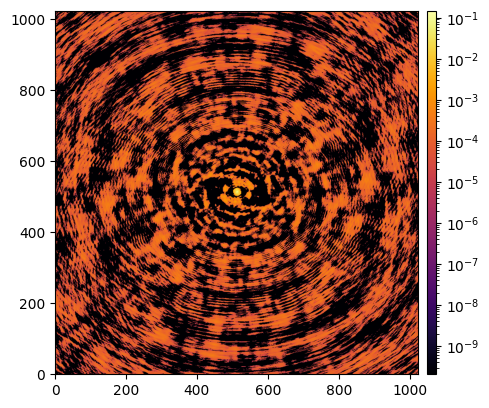

In [5]:
space_512 = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space_512)

kernel_512 = compute_psf_kernel(RNR_l)

plot_arrays(kernel_512, norm='log', dpi=100)

In [18]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')



exp_it = 3
sky_it = optim_cfg.instantiate_sec(f'sky.{exp_it}')

skies_c, means_c = [], []
with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    smp_c, *_ = pickle.load(f)
for sky_c in sky_it.signals + sky_it.points:
    print(sky_c.prefix)
    mean = smp_c.mean(sky_c)
    skies_c += [sky_c, ]
    means_c += [map_signal(mean, sky_c.space, skies_c[0].space), ]

bg.3
o0.3
o1.3
o2.3
p0.3


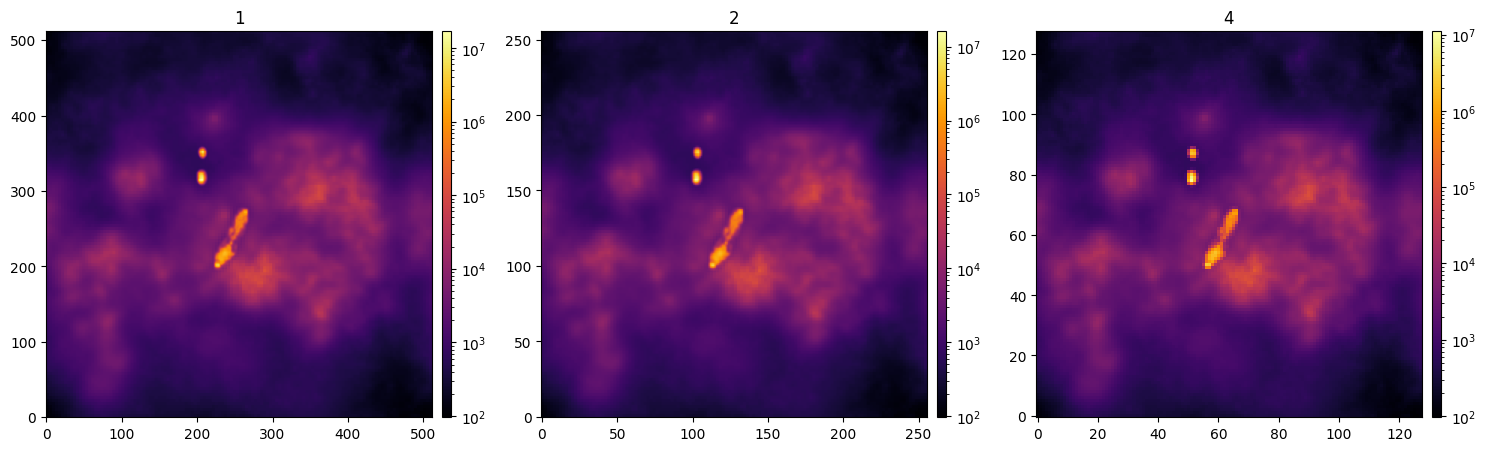

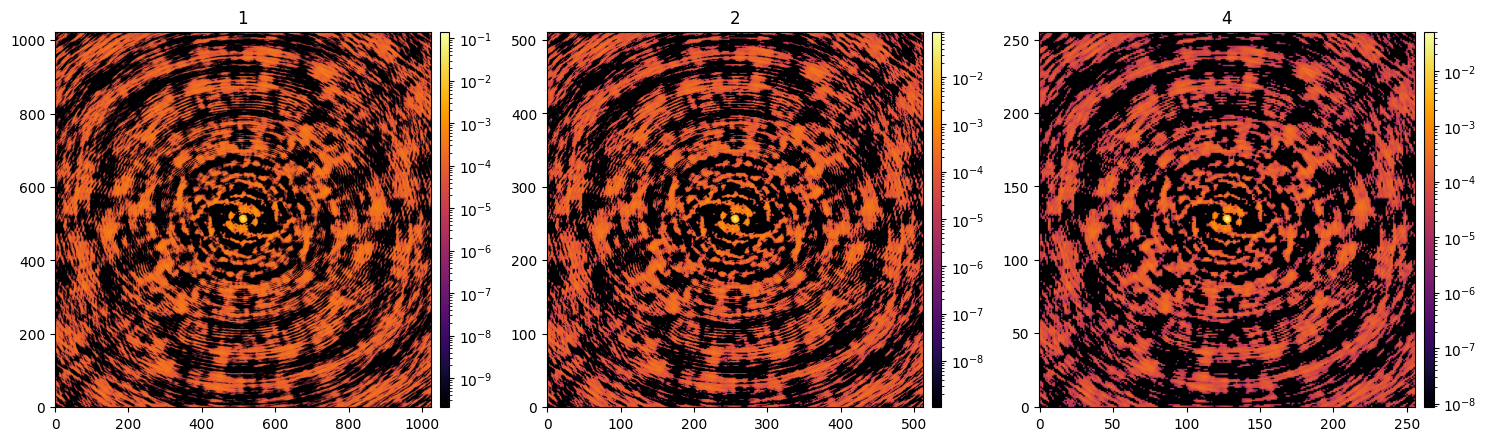

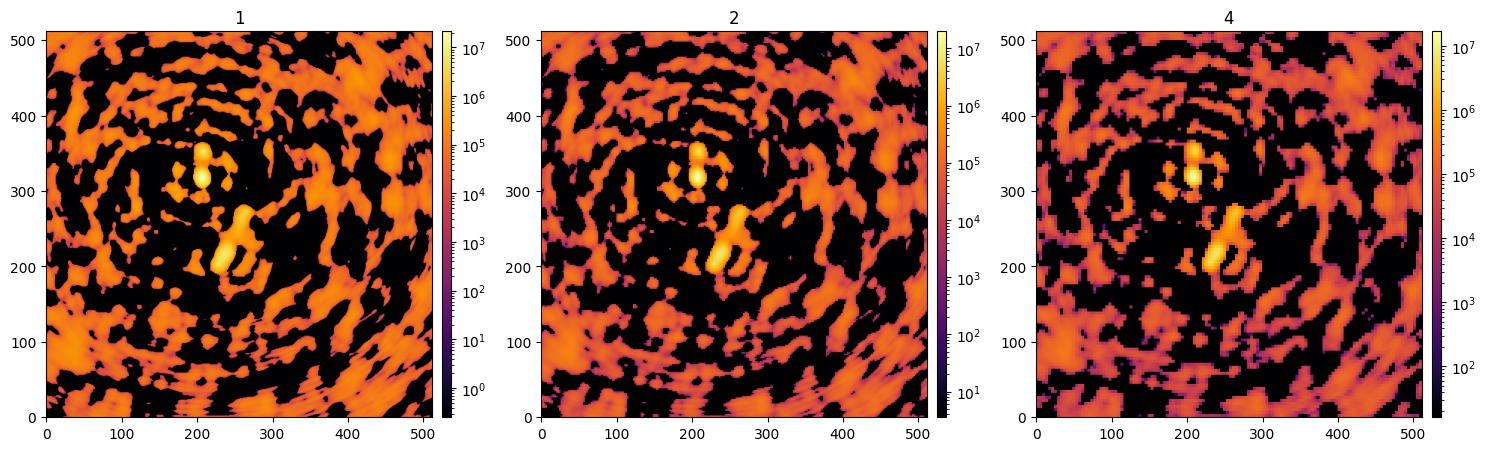

In [25]:
zoom = [1, 2, 4]

signal_bg, space_bg = upsample(downsample(means_c[0], max(zoom)), max(zoom)), skies_c[0].space * 0.5
signal_t0, space_t0 = means_c[1], skies_c[1].space * 0.5
signal_t1, space_t1 = means_c[2], skies_c[2].space * 0.5
signal_t2, space_t2 = means_c[3], skies_c[3].space * 0.5
signal = signal_bg + signal_t0 + signal_t1 + signal_t2


signal_dict = {}
for z in zoom:
    signal_dict[z] = downsample(signal, z)

kernel = kernel_512.copy()
kernel_dict = {}
for z in zoom:
    kernel_dict[z] = downsample(kernel, z)

response_dict = {}
for z in zoom:
    response_dict[z] = upsample(convolve(signal_dict[z], kernel_dict[z], mode='same', method='fft') * z**2, z)

pdict = {'rows': 1}
plot_arrays(list(signal_dict.values()), label=list(signal_dict.keys()), norm='log', **pdict)
plot_arrays(list(kernel_dict.values()), label=list(kernel_dict.keys()), norm='log', **pdict)
plot_arrays(list(response_dict.values()), label=list(response_dict.keys()), norm='log', **pdict)

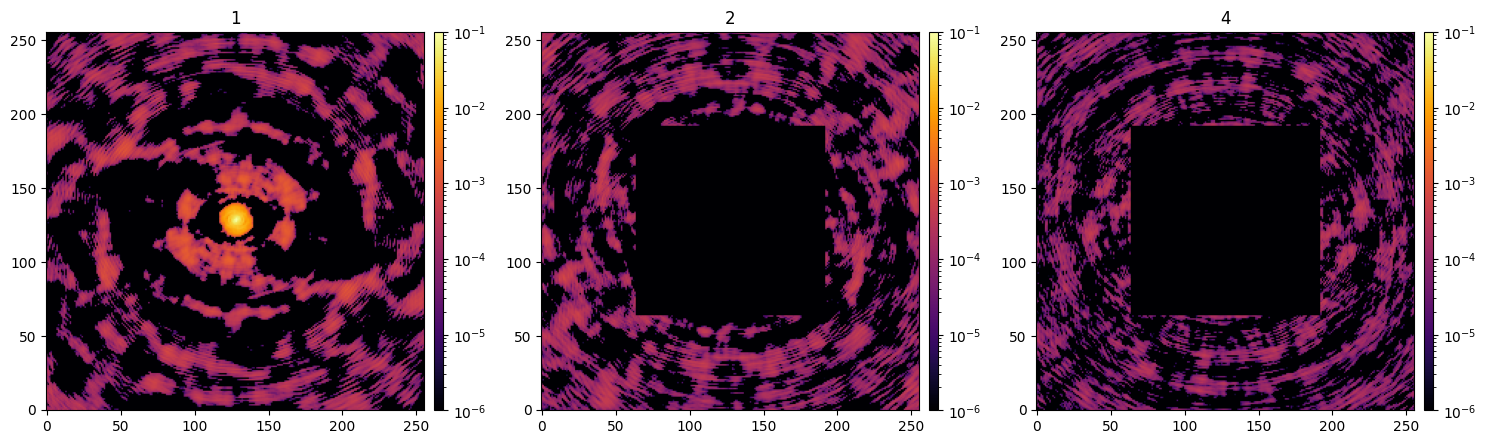

In [26]:
ksize = kernel.shape[0]
zsize = ksize // max(zoom)

kernel_split = {}
for i,z in enumerate(zoom):
    ker = np.zeros_like(kernel)
    if i == 0:
        slc_in = slice(0, 0)
        slc_out = slice(ksize//2 - zsize//2, ksize//2 + zsize//2)
    else:
        slc_in = slc_out
        slc_out = slice(ksize//2 - z*zsize//2, ksize//2 + z*zsize//2)
    ker[slc_out, slc_out] = kernel[slc_out, slc_out]
    ker[slc_in, slc_in] = 0
    kernel_split[z] = downsample(ker[slc_out, slc_out], z)

plot_arrays(list(kernel_split.values()), label=list(kernel_split.keys()), norm='log', **pdict, vmax=1e-1, vmin=1e-6)

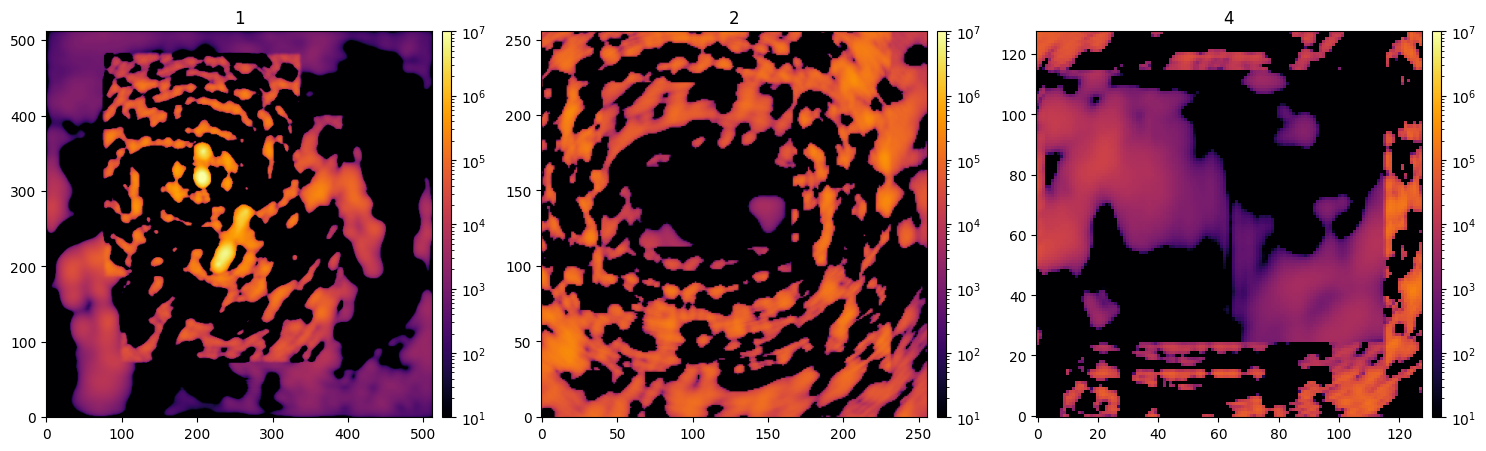

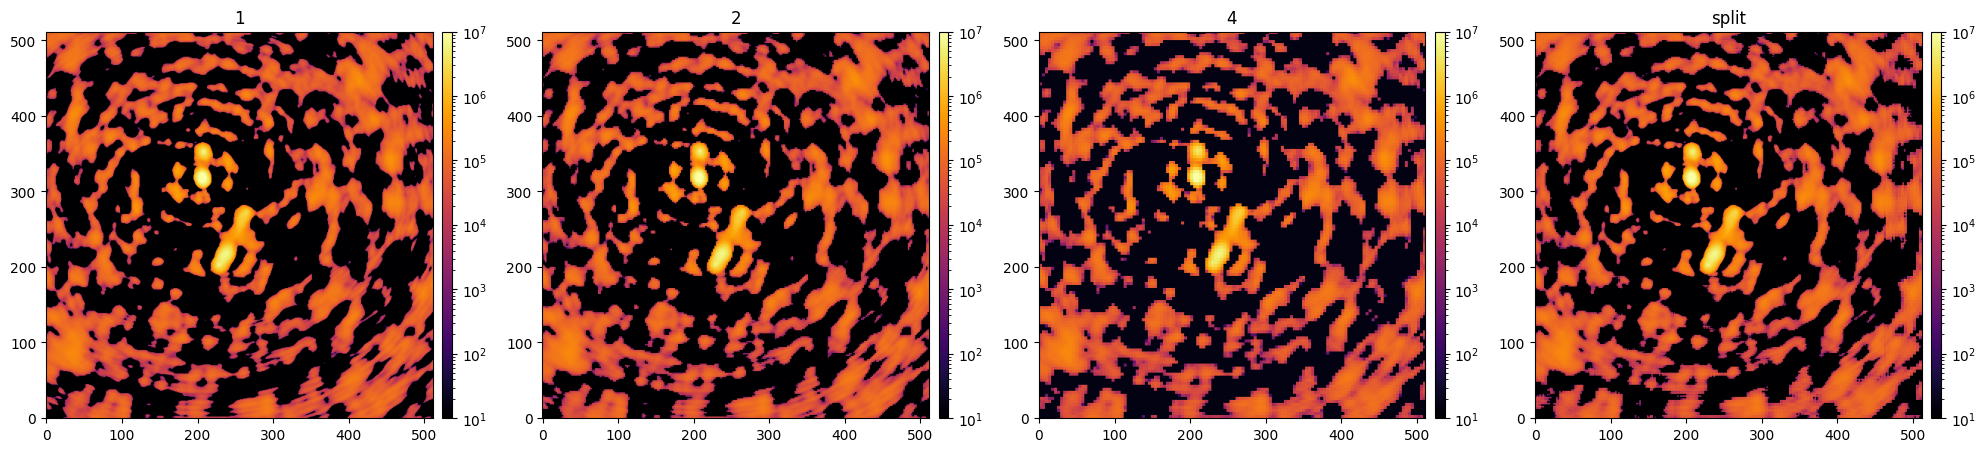

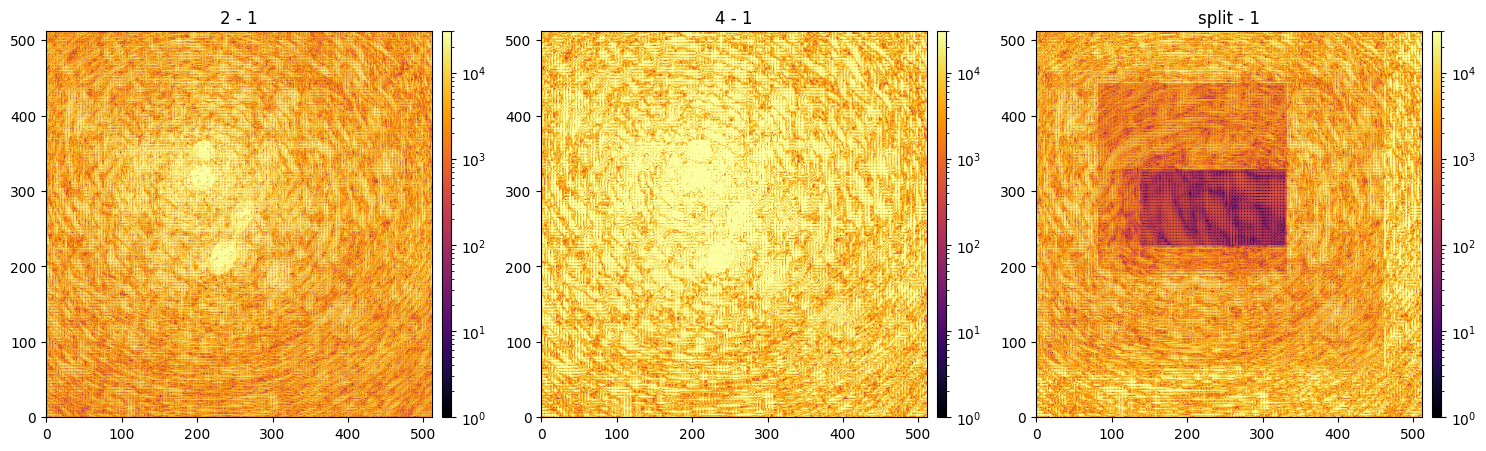

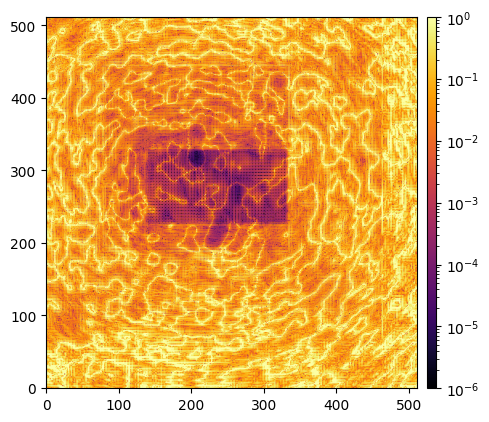

In [33]:
def multi_scale_kernel(signal_dict, kernel_split):

    response_split = kernel_split.copy()

    for z,k in kernel_split.items():
        response_split[z] = convolve(signal_dict[z], k, mode='same', method='fft') * z**2

    return response_split


response_split = multi_scale_kernel(signal_dict, kernel_split)

plot_arrays(list(response_split.values()), label=list(response_split.keys()), norm='log', **pdict, vmax=1e7, vmin=1e1)


response_sum = sum(upsample(rv, z) for z,rv in response_split.items())

rsp_val = list(response_dict.values()) + [response_sum]
rsp_key = list(response_dict.keys()) + ['split']

plot_arrays(rsp_val, label=rsp_key, norm='log', **pdict, vmax=1e7, vmin=1e1)


plot_arrays([np.abs(rv - response_dict[1]) for rv in rsp_val[1:]], label=[f'{rk} - 1' for rk in rsp_key[1:]], norm='log', **pdict, vmax=3e4, vmin=1)

plot_arrays(np.abs((response_sum - response_dict[1])/response_dict[1]), norm='log', **pdict, vmax=1, vmin=1e-6)